### Interpretation

The headline length distribution indicates that most financial headlines are concise and information-dense. This suggests that publishers prioritize rapid communication of market-relevant developments such as earnings releases, analyst actions, and price target revisions.

In [1]:
import os
import sys
import warnings

project_root = os.path.abspath("..")
sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## 1. Data Loading

The financial news dataset contains article headlines, publishers, publication dates, article URLs, and stock ticker symbols. These fields are used to explore how financial news is distributed across publishers, time, and companies.

In [2]:
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/stocks-that-hit-52-week-highs-on-friday,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/stocks-that-hit-52-week-highs-on-wednesday,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/71-biggest-movers-from-friday,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/46-stocks-moving-in-fridays-mid-day-session,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,"B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88",https://www.benzinga.com/news/20/05/16095304/b-of-a-securities-maintains-neutral-on-agilent-technologies-raises-pric...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
print(f"Rows: {news_df.shape[0]:,}")
print(f"Columns: {news_df.shape[1]}")

Rows: 1,407,328
Columns: 6


In [4]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


In [5]:
missing_values = news_df.isnull().sum().sort_values(ascending=False)
missing_values

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

### Data Quality Observation

The dataset was checked for missing values and column types before analysis. Date parsing is especially important because later stages require matching news publication dates with stock trading dates.

In [6]:
news_df.columns = news_df.columns.str.strip().str.lower()
news_df.head()

,unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/stocks-that-hit-52-week-highs-on-friday,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/stocks-that-hit-52-week-highs-on-wednesday,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/71-biggest-movers-from-friday,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/46-stocks-moving-in-fridays-mid-day-session,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,"B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88",https://www.benzinga.com/news/20/05/16095304/b-of-a-securities-maintains-neutral-on-agilent-technologies-raises-pric...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [7]:
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce", utc=True)

news_df["publication_date"] = news_df["date"].dt.date
news_df["publication_hour"] = news_df["date"].dt.hour
news_df["publication_day_name"] = news_df["date"].dt.day_name()
news_df["publication_month"] = news_df["date"].dt.to_period("M").astype(str)

news_df[["date", "publication_date", "publication_hour", "publication_day_name", "publication_month"]].head()

,date,publication_date,publication_hour,publication_day_name,publication_month
0,2020-06-05 14:30:54+00:00,2020-06-05,14.0,Friday,2020-06
1,2020-06-03 14:45:20+00:00,2020-06-03,14.0,Wednesday,2020-06
2,2020-05-26 08:30:07+00:00,2020-05-26,8.0,Tuesday,2020-05
3,2020-05-22 16:45:06+00:00,2020-05-22,16.0,Friday,2020-05
4,2020-05-22 15:38:59+00:00,2020-05-22,15.0,Friday,2020-05


## 2. Descriptive Statistics of Headlines

Headline length is analyzed because financial news headlines are often designed to quickly communicate market-moving information. Character count helps reveal whether headlines are short alerts, detailed summaries, or longer narrative-style updates.

In [8]:
news_df["headline"] = news_df["headline"].astype(str)
news_df["headline_length"] = news_df["headline"].apply(len)
news_df["headline_word_count"] = news_df["headline"].apply(lambda x: len(x.split()))

headline_summary = news_df[["headline_length", "headline_word_count"]].describe()
headline_summary

,headline_length,headline_word_count
count,1.407328e+06,1.407328e+06
mean,7.312051e+01,1.141671e+01
std,4.073531e+01,6.352997e+00
min,3.000000e+00,1.000000e+00
25%,4.700000e+01,7.000000e+00
50%,6.400000e+01,1.000000e+01
75%,8.700000e+01,1.300000e+01
max,5.120000e+02,7.700000e+01


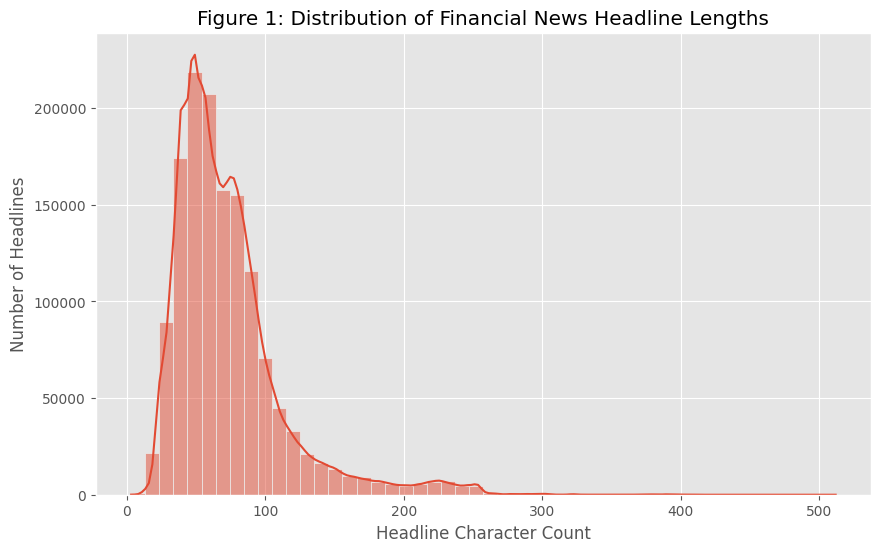

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(news_df["headline_length"], bins=50, kde=True)

plt.title("Figure 1: Distribution of Financial News Headline Lengths")
plt.xlabel("Headline Character Count")
plt.ylabel("Number of Headlines")

plt.show()

### Interpretation of Figure 1

Figure 1 shows that most financial headlines are concise and information-dense. This is expected in financial reporting, where publishers aim to communicate market-relevant updates quickly. Short, direct headlines are suitable for later sentiment analysis because they often contain clear signals such as upgrades, downgrades, earnings surprises, price target changes, or regulatory events.

In [10]:
news_df[["headline", "headline_length", "stock"]].sort_values(
    by="headline_length", ascending=False
).head(10)

,headline,headline_length,stock
701748,JinkoSolar Tiger Pro Series Receives World's First IEC 61701 Ed. 3 (FDIS) Certification for Salt Mist Corrosion Stan...,512,JKS
238137,"Check Point® Software Technologies Ltd. (NASDAQ:CHKP), a leading provider of cyber security solutions globally, is p...",509,CHKP
197884,Shares of several financial services companies are trading lower amid market weakness following US unemployment data...,458,BX
140381,Shares of several financial services companies are trading lower amid market weakness following US unemployment data...,458,BBDO
140048,Shares of several financial services companies are trading lower amid market weakness following US unemployment data...,458,BBD
316938,Shares of several financial services companies are trading lower amid market weakness following US unemployment data...,458,CVCY
416823,Shares of several financial services companies are trading lower amid market weakness following US unemployment data...,458,EMCF
1038290,Shares of several financial services companies are trading lower amid market weakness following US unemployment data...,458,PUK
39028,Shares of several financial services companies are trading lower amid market weakness following US unemployment data...,458,AFL
335711,Shares of several financial services companies are trading lower amid market weakness following US unemployment data...,458,DB


## 3. Publisher Analysis

Publisher analysis helps identify which sources contribute the largest share of financial news. This matters because a small number of highly active publishers may strongly influence the overall news sentiment distribution.

In [11]:
top_publishers = news_df["publisher"].value_counts().head(15)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64

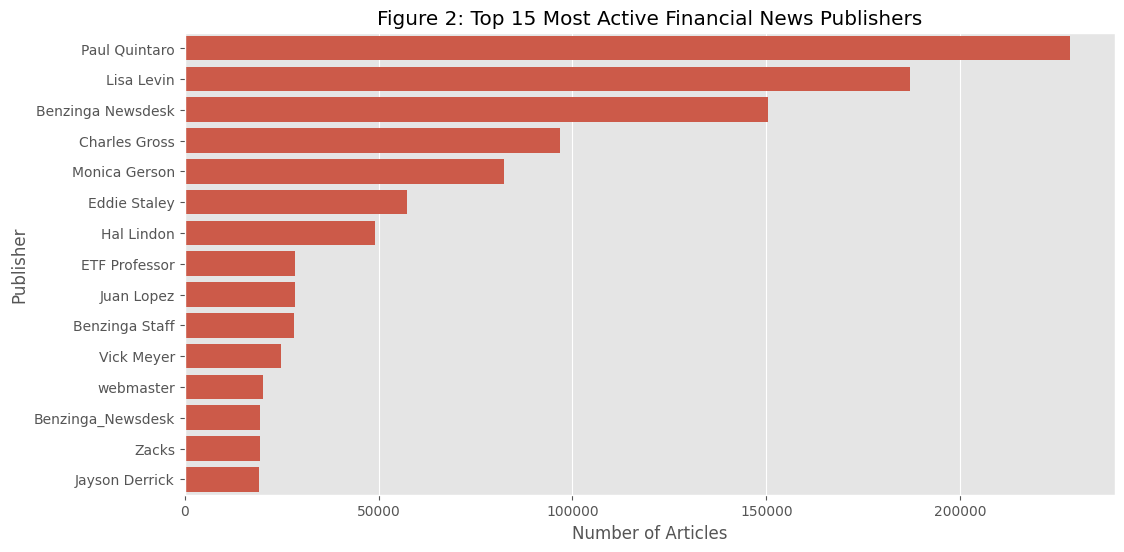

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title("Figure 2: Top 15 Most Active Financial News Publishers")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")

plt.show()

### Interpretation of Figure 2

Figure 2 shows that financial news production is concentrated among a limited number of highly active publishers. This concentration is important because dominant publishers may shape the tone and timing of market narratives that investors react to.

In [13]:
news_df["publisher_domain"] = news_df["publisher"].astype(str).str.extract(r"@([\w\.-]+)")

domain_counts = news_df["publisher_domain"].value_counts().head(10)

domain_counts

publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

### Publisher Domain Observation

Some publisher names appear in email format. Extracting domains allows organizational-level analysis instead of treating every email address as a separate publisher. This improves the quality of publisher analysis and supports the rubric requirement for domain extraction.

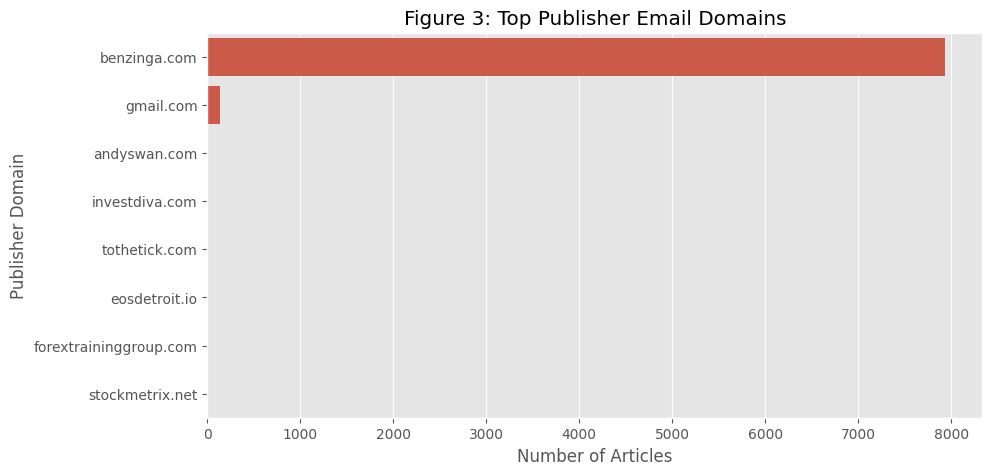

In [14]:
if len(domain_counts) > 0:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=domain_counts.values,
        y=domain_counts.index
    )

    plt.title("Figure 3: Top Publisher Email Domains")
    plt.xlabel("Number of Articles")
    plt.ylabel("Publisher Domain")

    plt.show()
else:
    print("No email-format publisher domains were detected.")

## 4. Stock Coverage Analysis

Stock coverage analysis identifies which ticker symbols receive the most attention in the news dataset. Stocks with higher coverage may provide stronger sample sizes for later sentiment-return correlation analysis.

In [15]:
top_stocks = news_df["stock"].value_counts().head(10)

top_stocks

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64

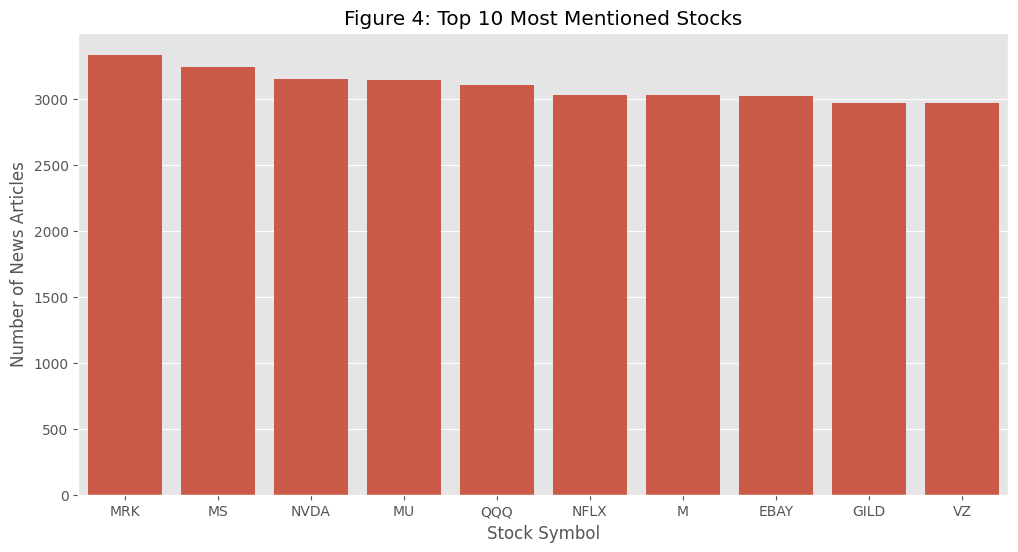

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_stocks.index,
    y=top_stocks.values
)

plt.title("Figure 4: Top 10 Most Mentioned Stocks")
plt.xlabel("Stock Symbol")
plt.ylabel("Number of News Articles")

plt.show()

### Interpretation of Figure 4

Figure 4 shows which stocks receive the highest media attention. Highly mentioned stocks are likely to be more suitable for the final correlation analysis because they provide more daily observations of news sentiment. Uneven stock coverage also highlights the need to interpret sentiment-return correlations carefully, since results may be stronger for stocks with richer news coverage.

## 5. Time-Series Analysis of News Volume

Publication frequency is analyzed over time to detect spikes in financial news activity. Spikes may indicate periods of elevated market attention, such as earnings announcements, analyst revisions, regulatory decisions, macroeconomic news, or company-specific events.

In [17]:
daily_news = news_df.groupby("publication_date").size().reset_index(name="article_count")
daily_news["publication_date"] = pd.to_datetime(daily_news["publication_date"])

daily_news.head()

,publication_date,article_count
0,2011-04-28,3
1,2011-04-29,2
2,2011-04-30,1
3,2011-05-01,1
4,2011-05-02,9


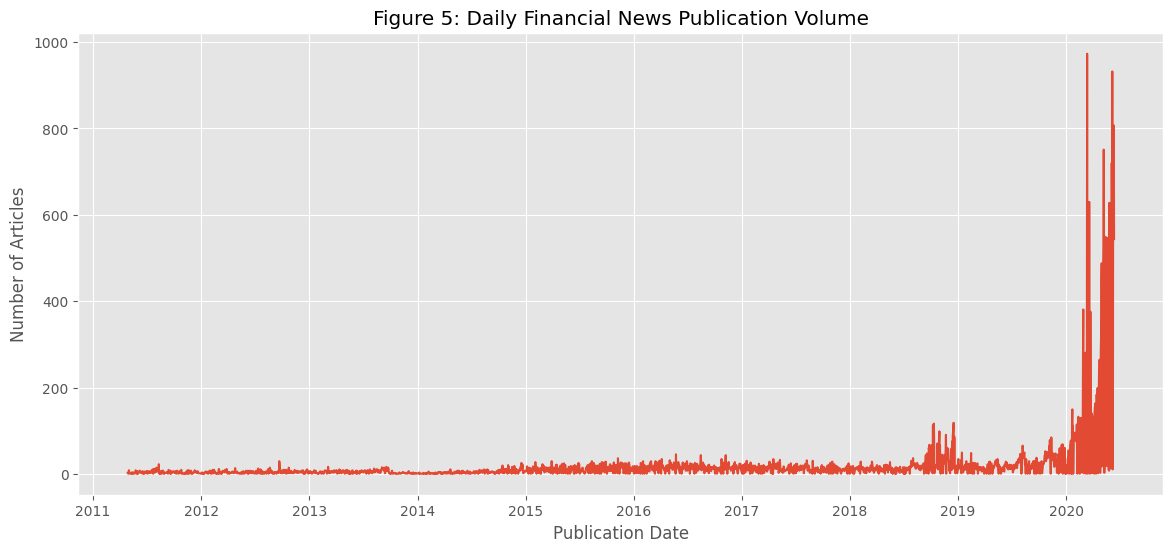

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(daily_news["publication_date"], daily_news["article_count"])

plt.title("Figure 5: Daily Financial News Publication Volume")
plt.xlabel("Publication Date")
plt.ylabel("Number of Articles")

plt.show()

### Interpretation of Figure 5

Figure 5 shows fluctuations in daily article volume across the dataset. Days with unusually high publication counts may represent periods of intensified financial activity. These spikes are important because heavy news flow can amplify investor attention and may correspond to stronger price movement or volatility.

In [19]:
spike_threshold = daily_news["article_count"].quantile(0.95)

spike_days = daily_news[daily_news["article_count"] >= spike_threshold].sort_values(
    by="article_count", ascending=False
)

spike_days.head(10)

,publication_date,article_count
2412,2020-03-12,973
2495,2020-06-05,932
2500,2020-06-10,807
2499,2020-06-09,803
2498,2020-06-08,765
2466,2020-05-07,751
2493,2020-06-03,720
2419,2020-03-19,630
2485,2020-05-26,628
2472,2020-05-13,549


### Spike-Day Observation

The highest-volume publication days were identified using the 95th percentile of daily article counts. These dates will be useful in the final stage when comparing sentiment intensity and stock returns around periods of unusually high news activity.

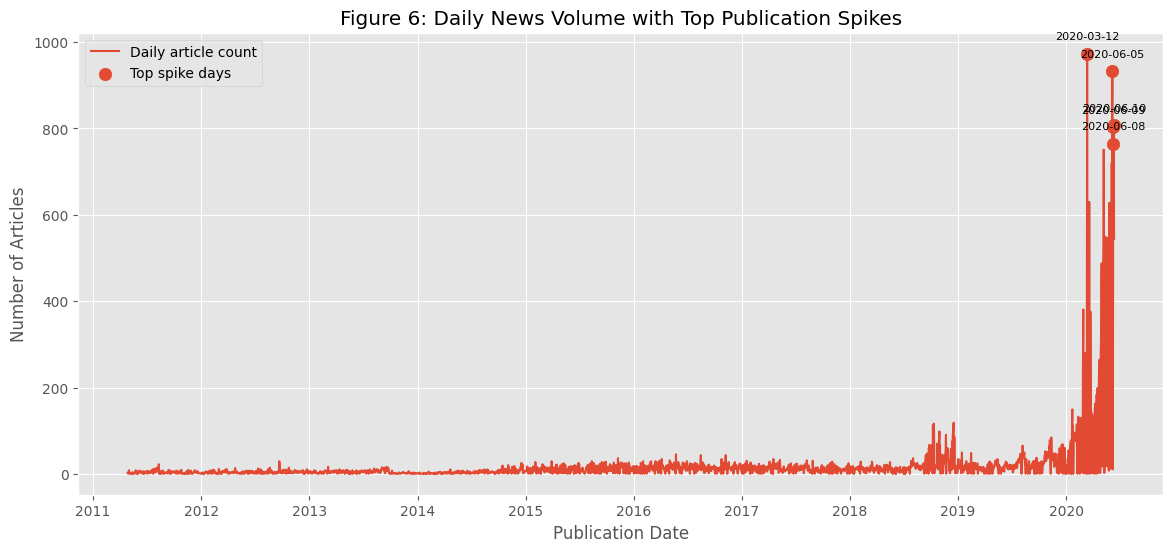

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(daily_news["publication_date"], daily_news["article_count"], label="Daily article count")

top_spikes = spike_days.head(5)

plt.scatter(
    top_spikes["publication_date"],
    top_spikes["article_count"],
    s=80,
    label="Top spike days"
)

for _, row in top_spikes.iterrows():
    plt.annotate(
        row["publication_date"].strftime("%Y-%m-%d"),
        (row["publication_date"], row["article_count"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8
    )

plt.title("Figure 6: Daily News Volume with Top Publication Spikes")
plt.xlabel("Publication Date")
plt.ylabel("Number of Articles")
plt.legend()

plt.show()

### Interpretation of Figure 6

Figure 6 highlights the largest publication spikes in the dataset. These spike days may reflect major corporate announcements, earnings-related news, analyst rating activity, or broader market events. In the final analysis, these dates should be examined more closely to determine whether abnormal news volume is associated with larger stock returns.

## 6. Publishing Time Analysis

The hour of publication is analyzed because the timing of news release can influence how quickly markets react. News released during trading hours may affect same-day price movement, while after-hours or weekend news may be reflected on the next trading day.

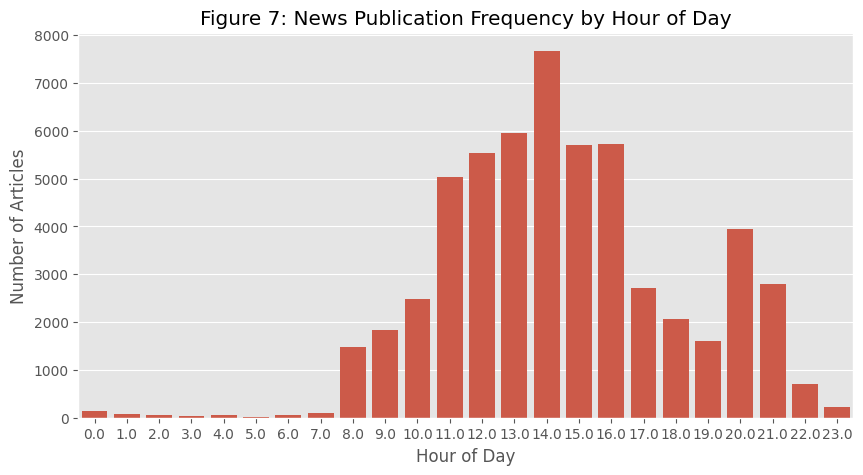

In [21]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x="publication_hour",
    data=news_df,
    order=sorted(news_df["publication_hour"].dropna().unique())
)

plt.title("Figure 7: News Publication Frequency by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")

plt.show()

### Interpretation of Figure 7

Figure 7 shows how news publication is distributed across the day. This is important for the final correlation analysis because publication timing affects whether a headline should be matched to the same trading day or the next trading day. Articles published outside normal trading hours may need special handling during date alignment.

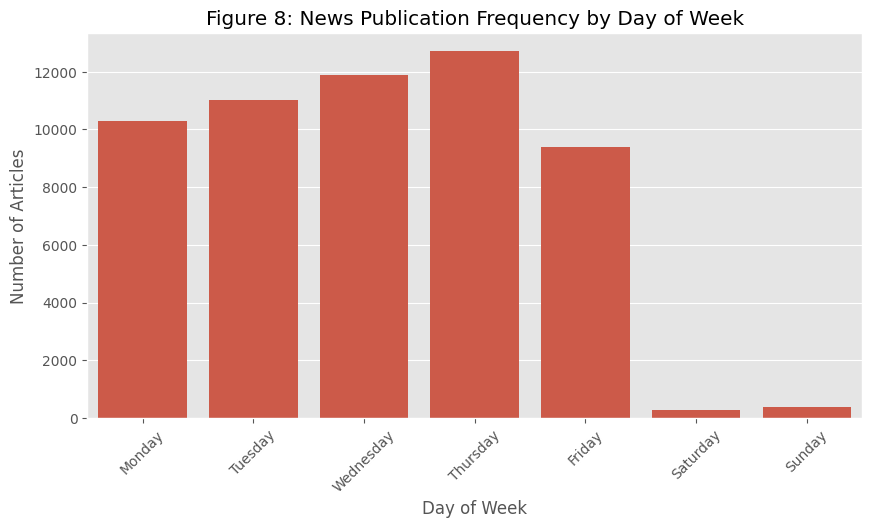

In [22]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 5))

sns.countplot(
    x="publication_day_name",
    data=news_df,
    order=day_order
)

plt.title("Figure 8: News Publication Frequency by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)

plt.show()

### Interpretation of Figure 8

Figure 8 shows whether article publication is concentrated on trading days or whether meaningful news also appears during weekends. Weekend publication is important because stock market data excludes non-trading days, so weekend news must be aligned to the next available trading day during Task 3.

## 7. Keyword and Topic Analysis

Keyword analysis is used to identify recurring financial themes in the headlines. This provides an early view of the types of market narratives present in the dataset before formal sentiment scoring is applied.

In [23]:
count_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=25,
    ngram_range=(1, 2)
)

count_matrix = count_vectorizer.fit_transform(news_df["headline"].astype(str))

keyword_counts = pd.DataFrame({
    "keyword": count_vectorizer.get_feature_names_out(),
    "frequency": count_matrix.toarray().sum(axis=0)
}).sort_values(by="frequency", ascending=False)

keyword_counts.head(25)

,keyword,frequency
23,vs,162099
18,stocks,161776
8,est,140604
7,eps,128897
10,market,120558
17,shares,114313
15,reports,108710
21,update,91723
6,earnings,87399
16,sales,79645


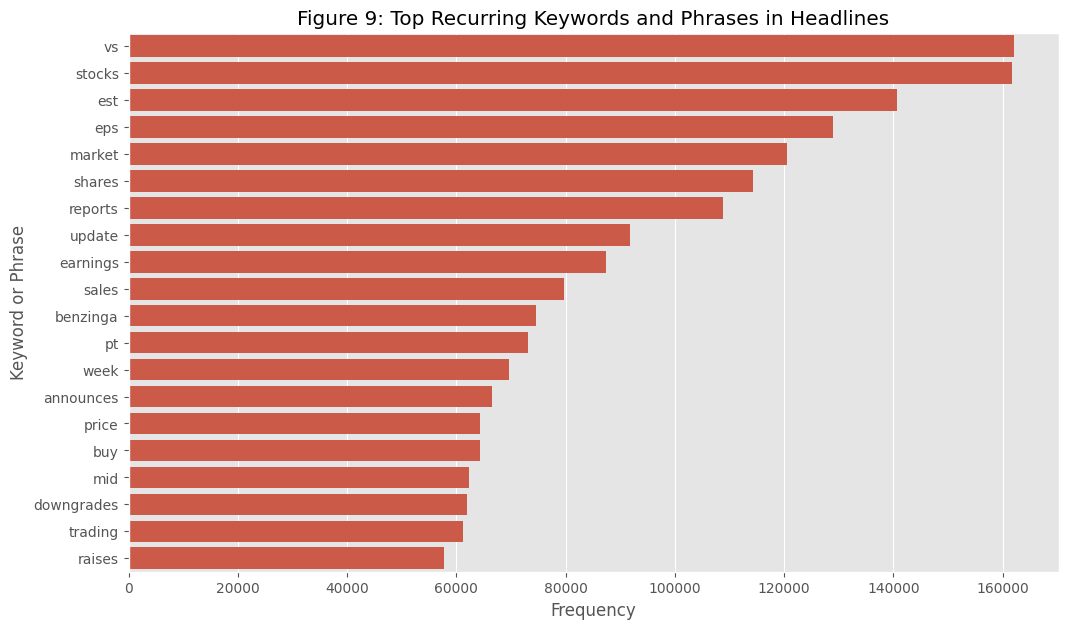

In [24]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x="frequency",
    y="keyword",
    data=keyword_counts.head(20)
)

plt.title("Figure 9: Top Recurring Keywords and Phrases in Headlines")
plt.xlabel("Frequency")
plt.ylabel("Keyword or Phrase")

plt.show()

### Interpretation of Figure 9

Figure 9 shows recurring terms and phrases in the headline text. These keywords help identify dominant financial themes such as earnings, analyst ratings, price targets, upgrades, downgrades, and company-specific announcements. These themes are likely to influence investor expectations and will be useful when interpreting sentiment scores.

In [25]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=25,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(news_df["headline"].astype(str))

tfidf_scores = pd.DataFrame({
    "term": tfidf_vectorizer.get_feature_names_out(),
    "tfidf_score": tfidf_matrix.mean(axis=0).A1
}).sort_values(by="tfidf_score", ascending=False)

tfidf_scores.head(25)

,term,tfidf_score
18,stocks,0.077849
10,market,0.058468
17,shares,0.054802
6,earnings,0.053301
23,vs,0.046377
15,reports,0.045487
21,update,0.044131
7,eps,0.043306
3,benzinga,0.041270
2,announces,0.038739


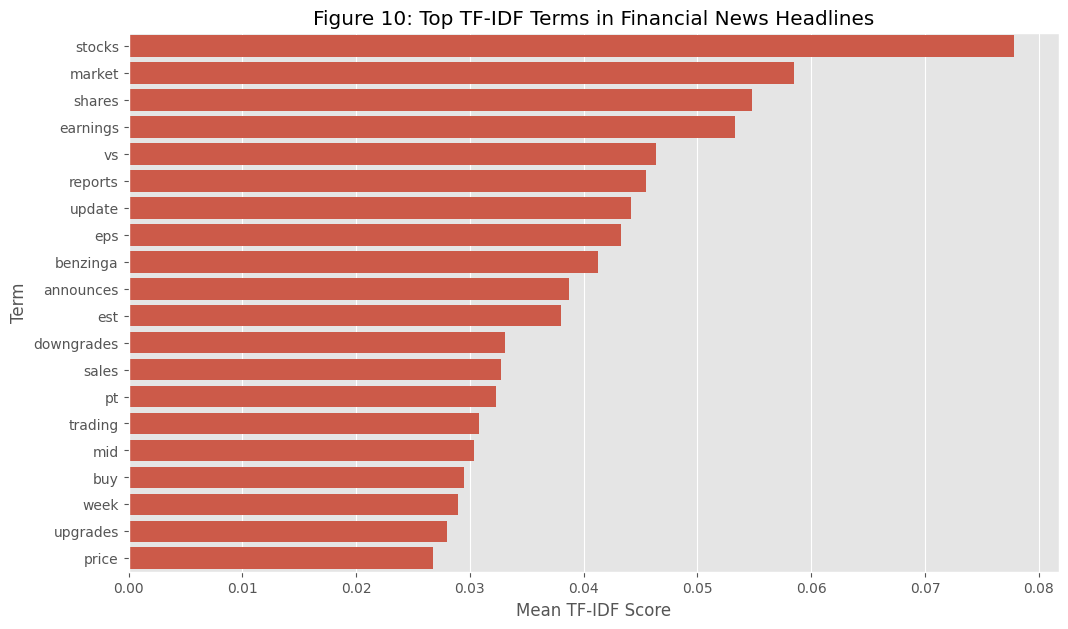

In [26]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x="tfidf_score",
    y="term",
    data=tfidf_scores.head(20)
)

plt.title("Figure 10: Top TF-IDF Terms in Financial News Headlines")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")

plt.show()

### Interpretation of Figure 10

Figure 10 presents important headline terms using TF-IDF, which gives more weight to distinctive terms rather than simply frequent words. This helps identify meaningful financial signals and avoids relying only on high-frequency generic words.

## 8. Preliminary EDA Findings

The exploratory analysis produced several important findings:

1. **Headline structure:** Financial news headlines are generally concise and event-driven, making them suitable for sentiment analysis.
2. **Publisher concentration:** A limited number of publishers account for a large share of the dataset, suggesting that dominant sources may influence the overall tone of market news.
3. **Stock coverage imbalance:** Some ticker symbols receive substantially more coverage than others, which will affect the reliability of stock-specific sentiment-return correlation analysis.
4. **News volume spikes:** Publication volume is not uniform over time. Spike days may represent major market or corporate events and should be examined carefully in the final analysis.
5. **Publication timing matters:** Hour-of-day and day-of-week patterns show that date alignment must be handled carefully, especially for after-hours and weekend articles.
6. **Recurring financial themes:** Keyword and TF-IDF analysis identified recurring market narratives that likely include earnings, analyst ratings, price targets, and stock movement language.

These findings will guide the sentiment analysis and correlation pipeline in Task 3.

## 9. Relevance to the Business Objective

This EDA supports Nova Financial Solutions' broader objective of building a pipeline that connects market narratives to price action. By understanding who publishes financial news, when articles are released, which stocks receive coverage, and what themes dominate headlines, the analysis creates a foundation for measuring whether sentiment contains useful predictive information for stock movement.

The next phase will combine this news dataset with historical stock price data, compute technical indicators, and align daily sentiment scores with stock returns.

In [27]:
processed_path = "../data/raw/news_cleaned_interim.csv"

news_df.to_csv(processed_path, index=False)

print(f"Cleaned interim news dataset saved to: {processed_path}")

Cleaned interim news dataset saved to: ../data/raw/news_cleaned_interim.csv


## 10. Next Steps

The next steps are:

- Load historical stock price datasets for selected tickers.
- Check stock price data quality and missing values.
- Compute initial technical indicators such as SMA, EMA, and RSI.
- Visualize stock closing prices with technical indicators.
- Prepare the interim report using the EDA findings and initial stock analysis.
- In the final submission, align news dates with trading dates, compute sentiment scores, calculate daily returns, and measure Pearson correlation between sentiment and stock movement.